In [1]:
# ── Notebook 03 — Layer 2A Experiments (Kaggle, rebuilt for CRC) ─────────────
# Trains Isolation Forest + Shallow Autoencoder on the corrected 29-dim,
# family-aware Notebook 02 splits. Threshold selection: recall-maximization
# subject to FPR ≤ 5%, swept on normal-only validation, bounded to
# [normal_P50, normal_P99] — never on a mixed val set (see prior notebook's
# bug: F1-maximizing a sweep on a 606-normal/11,955-attack mixed pool
# collapsed Autoencoder recall to 0.56 and let Isolation Forest FPR hit 14.6%).

import sys, os
from pathlib import Path

PROJECT = "/kaggle/working"
sys.path.insert(0, PROJECT)
os.chdir(PROJECT)
print(f"Working dir: {os.getcwd()}")

Working dir: /kaggle/working


In [2]:
%%capture
!pip install scikit-learn xgboost tensorflow onnx onnxruntime \
             skl2onnx tf2onnx joblib tqdm seaborn scipy pandas

In [3]:
import sys
from pathlib import Path

DATASET_ROOT = Path("/kaggle/input/datasets/surathbob/hiwaf-split-v1")

sys.path.insert(0, str(DATASET_ROOT))

In [4]:
# %% [code] — Cell 4: imports, load splits, guards, scaling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from feature_engineering.normalizer import Normalizer
from feature_engineering.extractor import FEATURE_NAMES, INPUT_DIM

# ── paths ──────────────────────────────────────────────────────────────────
DATA_SPLITS = Path("/kaggle/input/datasets/surathbob/hiwaf-split-v1/data/splits")
SCALER_PATH = Path("/kaggle/input/datasets/surathbob/hiwaf-split-v1/exported_models/scaler_l2a.pkl")
MODEL_DIR   = Path("/kaggle/working/exported_models")
RESULTS_DIR = Path("/kaggle/working/results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── load splits ────────────────────────────────────────────────────────────
X_n_train    = np.load(DATA_SPLITS / "l2a_normal_train.npy")
X_n_val      = np.load(DATA_SPLITS / "l2a_normal_val.npy")     # normal only — FPR
X_attack_val = np.load(DATA_SPLITS / "l2a_attack_val.npy")     # attack only — TPR
X_test       = np.load(DATA_SPLITS / "l2a_test_X.npy")         # mixed
y_test       = np.load(DATA_SPLITS / "l2a_test_y.npy")

# ── guard: fail loud if this is pointed at stale/pre-CRC data ──────────────
# EXPECTED_INPUT_DIM is kept as an explicit literal (not derived from
# INPUT_DIM) so this check actually catches a stale extractor import instead
# of trivially comparing INPUT_DIM to itself.
EXPECTED_INPUT_DIM = 29
assert INPUT_DIM == EXPECTED_INPUT_DIM, (
    f"Expected INPUT_DIM={EXPECTED_INPUT_DIM} (post domain-strip/JSON features), got {INPUT_DIM}"
)
for name, arr in [("X_n_train", X_n_train), ("X_n_val", X_n_val),
                   ("X_attack_val", X_attack_val), ("X_test", X_test)]:
    assert arr.shape[1] == INPUT_DIM, (
        f"{name} has {arr.shape[1]} features, expected {INPUT_DIM} — stale Notebook 02 output?"
    )

print(f"Shape check passed — all splits are {INPUT_DIM}-dim.")
print(f"  train (normal):        {X_n_train.shape}")
print(f"  val   (normal only):   {X_n_val.shape}")
print(f"  val   (attack only):   {X_attack_val.shape}")
print(f"  test  (mixed):         {X_test.shape}  attack_rate={y_test.mean():.1%}")

# ── load scaler (transform only — already fit in Notebook 02) ──────────────
norm = Normalizer.load(str(SCALER_PATH))
assert norm._scaler.n_features_in_ == INPUT_DIM, "Scaler was fit on a different feature dimension — stale scaler?"

X_n_train_s    = norm.transform(X_n_train)
X_n_val_s      = norm.transform(X_n_val)
X_attack_val_s = norm.transform(X_attack_val)
X_test_s       = norm.transform(X_test)

print("\nScaling applied (transform only, scaler unchanged).")

Shape check passed — all splits are 29-dim.
  train (normal):        (3791, 29)
  val   (normal only):   (606, 29)
  val   (attack only):   (10533, 29)
  test  (mixed):         (10789, 29)  attack_rate=94.4%
[Normalizer] Loaded from /kaggle/input/datasets/surathbob/hiwaf-split-v1/exported_models/scaler_l2a.pkl

Scaling applied (transform only, scaler unchanged).


In [5]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-08-08 18:23:35.609714: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "shallow_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │           609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,883 (7.36 KB)

 Trainable params: 1,883 (7.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3687 - val_loss: 0.4276
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2630 - val_loss: 0.1870
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1204 - val_loss: 0.0608
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0553 - val_loss: 0.0371
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0342 - val_loss: 0.0331
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0264 - val_loss: 0.0296
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0224 - val_loss: 0.0262
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0195 - val_loss: 0.0238
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 - val_loss: 0.0219
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157 - val_loss: 0.0197
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - val_loss: 0.0175
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

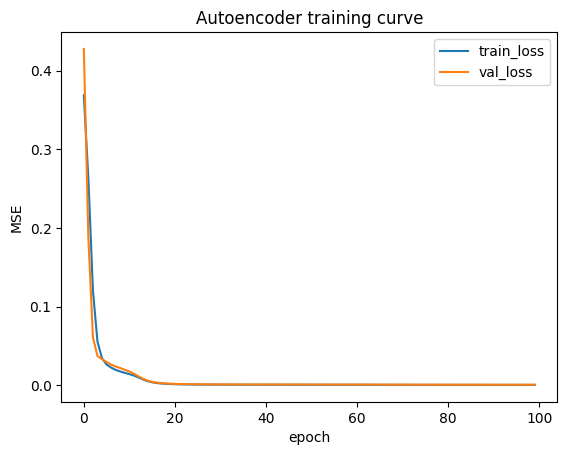

In [6]:
# %% [code] — Cell 5: build & train Shallow Autoencoder
def build_autoencoder(input_dim: int) -> Model:
    inp = Input(shape=(input_dim,))
    x   = Dense(20, activation="relu")(inp)
    x   = Dense(12, activation="relu")(x)
    x   = Dense(6,  activation="relu")(x)   # bottleneck
    x   = Dense(12, activation="relu")(x)
    x   = Dense(20, activation="relu")(x)
    out = Dense(input_dim, activation="linear")(x)
    model = Model(inp, out, name="shallow_autoencoder")
    model.compile(optimizer="adam", loss="mse")
    return model

autoencoder = build_autoencoder(INPUT_DIM)   # FIX: was hardcoded 29
autoencoder.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = autoencoder.fit(
    X_n_train_s, X_n_train_s,
    validation_data=(X_n_val_s, X_n_val_s),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

def ae_anomaly_score(X):
    recon = autoencoder.predict(X, verbose=0)
    return np.mean(np.square(X - recon), axis=1)   # reconstruction MSE — higher = more anomalous

ae_score_n_val      = ae_anomaly_score(X_n_val_s)
ae_score_attack_val = ae_anomaly_score(X_attack_val_s)
ae_score_test       = ae_anomaly_score(X_test_s)

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend(); plt.title("Autoencoder training curve"); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.savefig(RESULTS_DIR / "ae_training_curve.png", dpi=120)
plt.show()

In [7]:
# %% [code] — Cell 6: train Isolation Forest
print("=" * 70)
print("Training Isolation Forest")
print("=" * 70)

iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

t0 = time.perf_counter()
iso.fit(X_n_train_s)
iso_train_time = time.perf_counter() - t0

print(f"Training completed in {iso_train_time:.2f} s")

Training Isolation Forest
Training completed in 0.73 s


In [8]:
# %% [code] — Cell 7: Isolation Forest anomaly scores
# Larger score = more anomalous
iso_score_n_val      = -iso.decision_function(X_n_val_s)
iso_score_attack_val = -iso.decision_function(X_attack_val_s)
iso_score_test       = -iso.decision_function(X_test_s)

print("\nIsolation Forest score statistics")
print(f"Normal validation : {iso_score_n_val.min():.4f} → {iso_score_n_val.max():.4f}")
print(f"Attack validation : {iso_score_attack_val.min():.4f} → {iso_score_attack_val.max():.4f}")


Isolation Forest score statistics
Normal validation : -0.1012 → 0.1857
Attack validation : -0.0895 → 0.2282


In [9]:
# %% [code] — Cell 8: threshold calibration
def calibrate_threshold(score_normal_val: np.ndarray, score_attack_val: np.ndarray,
                         fpr_cap: float = 0.05, n_steps: int = 500):
    """
    Recall-maximization subject to FPR ≤ fpr_cap.

    Sweep bounded to [P50, P99] of normal_val scores. Rule: among thresholds
    achieving FPR ≤ fpr_cap, pick the LOWEST threshold (= highest recall). If
    none satisfy the cap within the bound, fall back to the lowest-FPR point
    available and warn loudly rather than silently violating the constraint.
    """
    p_lo, p_hi = np.percentile(score_normal_val, [50, 99])
    thresholds = np.linspace(p_lo, p_hi, n_steps)

    results = []
    for t in thresholds:
        fpr = np.mean(score_normal_val > t)
        tpr = np.mean(score_attack_val > t)
        results.append((t, fpr, tpr))
    results = np.array(results)  # columns: threshold, fpr, tpr

    valid = results[results[:, 1] <= fpr_cap]

    if len(valid) == 0:
        raise RuntimeError(
            f"No threshold in [P50,P99] satisfies FPR <= {fpr_cap:.2%}"
        )
    
    # Sort by:
    # 1. Highest Recall
    # 2. Lowest FPR
    # 3. Lowest Threshold
    
    order = np.lexsort((
        valid[:,0],      # threshold ascending
        valid[:,1],      # FPR ascending
        -valid[:,2],     # Recall descending
    ))
    
    best = valid[order[0]]
    
    status = "ok"

    return {
        "threshold": float(best[0]),
        "fpr":       float(best[1]),
        "recall":    float(best[2]),
        "p_lo": float(p_lo), "p_hi": float(p_hi),
        "status": status,
        "sweep": results,
    }

print("Calibrating Isolation Forest threshold...")
iso_calib = calibrate_threshold(iso_score_n_val, iso_score_attack_val, fpr_cap=0.05)
print(f"  threshold={iso_calib['threshold']:.4f}  FPR={iso_calib['fpr']:.4f}  Recall={iso_calib['recall']:.4f}")

print("\nCalibrating Autoencoder threshold...")
ae_calib = calibrate_threshold(ae_score_n_val, ae_score_attack_val, fpr_cap=0.05)
print(f"  threshold={ae_calib['threshold']:.6f}  FPR={ae_calib['fpr']:.4f}  Recall={ae_calib['recall']:.4f}")

Calibrating Isolation Forest threshold...
  threshold=0.1376  FPR=0.0495  Recall=0.1987

Calibrating Autoencoder threshold...
  threshold=0.002985  FPR=0.0396  Recall=0.8237


In [10]:
pd.DataFrame(
    iso_calib["sweep"],
    columns=[
        "threshold",
        "fpr",
        "recall"
    ]
).to_csv(
    RESULTS_DIR /
    "iso_threshold_sweep.csv",
    index=False
)

pd.DataFrame(
    ae_calib["sweep"],
    columns=[
        "threshold",
        "fpr",
        "recall"
    ]
).to_csv(
    RESULTS_DIR /
    "ae_threshold_sweep.csv",
    index=False
)

In [11]:
# %% [code] — Cell 9: candidate evaluation & winner selection
def evaluate_candidate(name, score_test, y_test, threshold):
    y_pred = (score_test > threshold).astype(int)
    return {
        "Model":     name,
        "ROC_AUC":   roc_auc_score(y_test, score_test),
        "PR_AUC":    average_precision_score(y_test, score_test),
        "Recall":    recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "FPR":       np.mean(score_test[y_test == 0] > threshold),
        "F1":        f1_score(y_test, y_pred),
        "Threshold": threshold,
    }

iso_result = evaluate_candidate("Isolation Forest", iso_score_test, y_test, iso_calib["threshold"])
ae_result  = evaluate_candidate("Shallow Autoencoder", ae_score_test, y_test, ae_calib["threshold"])

comparison = pd.DataFrame([iso_result, ae_result])
comparison.to_csv(RESULTS_DIR / "table1_l2a_candidate_comparison.csv", index=False)

print("Table I — Layer 2A Candidate Comparison (test set, for reporting only)")
print(comparison.to_string(index=False))

# ------------------------------------------------------------
# Winner selection
# ------------------------------------------------------------
# CHANGED: winner is now selected from VALIDATION-time calibration results
# (iso_calib / ae_calib), not from the test-set `comparison` table above.
# The test set is for final unbiased reporting only — using it to pick the
# winner would be a mild form of leakage into model selection, the same
# category of mistake the family-aware split exists to prevent elsewhere
# in this pipeline.
#
# Selection rule (applied on validation):
#   - FPR <= 5% (enforced already, inside calibrate_threshold)
#   - Maximum Recall
#   - Lowest FPR (tie-break)
#   - Lowest Threshold (final tie-break)
# ------------------------------------------------------------

val_candidates = pd.DataFrame([
    {"Model": "Isolation Forest",    "Recall": iso_calib["recall"], "FPR": iso_calib["fpr"], "Threshold": iso_calib["threshold"]},
    {"Model": "Shallow Autoencoder", "Recall": ae_calib["recall"],  "FPR": ae_calib["fpr"],  "Threshold": ae_calib["threshold"]},
])

winner_row = (
    val_candidates
    .sort_values(["Recall", "FPR", "Threshold"], ascending=[False, True, True])
    .iloc[0]
)

winner_name = winner_row["Model"]

print(f"\nWinner (selected on validation): {winner_name}")
print(f"  validation Recall={winner_row['Recall']:.4f}  FPR={winner_row['FPR']:.4f}  Threshold={winner_row['Threshold']}")

Table I — Layer 2A Candidate Comparison (test set, for reporting only)
              Model  ROC_AUC   PR_AUC   Recall  Precision      FPR       F1  Threshold
   Isolation Forest 0.800180 0.982866 0.202435   0.984248 0.054726 0.335803   0.137571
Shallow Autoencoder 0.963961 0.997732 0.821323   0.997021 0.041459 0.900684   0.002985

Winner (selected on validation): Shallow Autoencoder
  validation Recall=0.8237  FPR=0.0396  Threshold=0.0029852040629296923


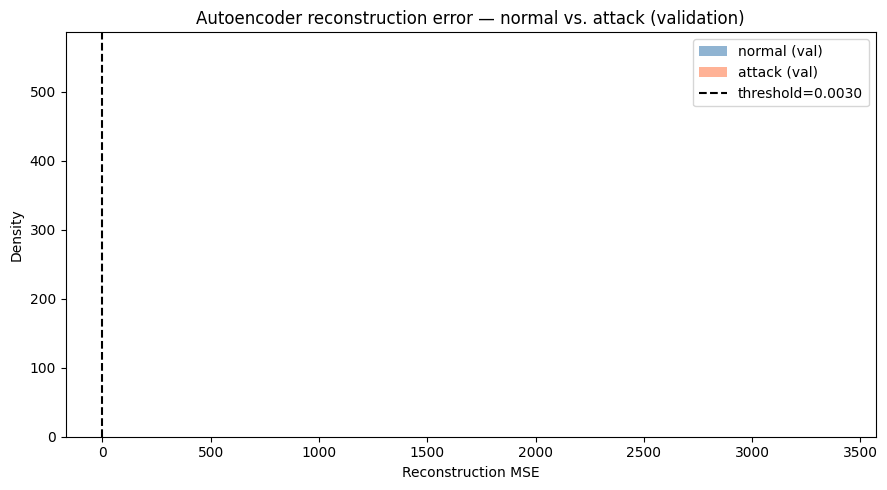

In [12]:
# %% [code] — Cell 10: AE reconstruction-error distribution plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ae_score_n_val, bins=50, alpha=0.6, label="normal (val)", color="steelblue", density=True)
ax.hist(ae_score_attack_val, bins=50, alpha=0.6, label="attack (val)", color="coral", density=True)
ax.axvline(ae_calib["threshold"], color="black", linestyle="--", label=f"threshold={ae_calib['threshold']:.4f}")
ax.set_xlabel("Reconstruction MSE")
ax.set_ylabel("Density")
ax.set_title("Autoencoder reconstruction error — normal vs. attack (validation)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ae_reconstruction_error_dist.png", dpi=120)
plt.show()

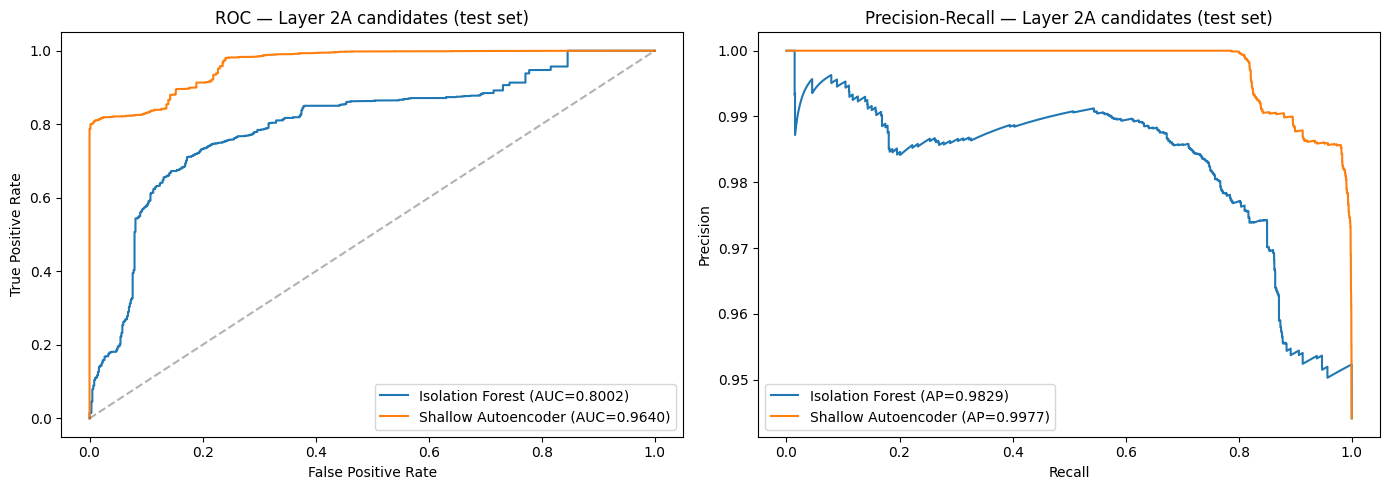

In [13]:
# %% [code] — Cell 11: ROC / PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, score in [("Isolation Forest", iso_score_test), ("Shallow Autoencoder", ae_score_test)]:
    fpr_curve, tpr_curve, _ = roc_curve(y_test, score)
    axes[0].plot(fpr_curve, tpr_curve, label=f"{name} (AUC={roc_auc_score(y_test, score):.4f})")

    prec_curve, rec_curve, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec_curve, prec_curve, label=f"{name} (AP={average_precision_score(y_test, score):.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — Layer 2A candidates (test set)"); axes[0].legend()

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — Layer 2A candidates (test set)"); axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "l2a_roc_pr_curves.png", dpi=120)
plt.show()

In [14]:
# %% [code] — Cell 12: bootstrap confidence intervals for the winner
def bootstrap_ci(score_test, y_test, threshold, n_bootstrap=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_test)
    f1s, fprs, recalls = [], [], []

    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        s_b, y_b = score_test[idx], y_test[idx]
        y_pred_b = (s_b > threshold).astype(int)
        if y_b.sum() == 0 or (1 - y_b).sum() == 0:
            continue   # skip degenerate resamples (all one class)
        f1s.append(f1_score(y_b, y_pred_b))
        fprs.append(np.mean(s_b[y_b == 0] > threshold) if (y_b == 0).sum() > 0 else np.nan)
        recalls.append(recall_score(y_b, y_pred_b))

    def ci(vals):
        vals = np.array(vals)
        vals = vals[~np.isnan(vals)]
        return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5)), float(np.mean(vals))

    return {
        "F1":     ci(f1s),
        "FPR":    ci(fprs),
        "Recall": ci(recalls),
    }

winner_score     = iso_score_test if winner_name == "Isolation Forest" else ae_score_test
winner_threshold = iso_calib["threshold"] if winner_name == "Isolation Forest" else ae_calib["threshold"]

ci_results = bootstrap_ci(winner_score, y_test, winner_threshold, n_bootstrap=1000)

print(f"Bootstrap 95% CIs — {winner_name} (n=1000 resamples)")
for metric, (lo, hi, mean) in ci_results.items():
    print(f"  {metric}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

with open(RESULTS_DIR / "l2a_bootstrap_ci.json", "w") as f:
    json.dump({"model": winner_name, "n_bootstrap": 1000,
               "ci": {k: {"mean": v[2], "ci_low": v[0], "ci_high": v[1]} for k, v in ci_results.items()}},
              f, indent=2)

Bootstrap 95% CIs — Shallow Autoencoder (n=1000 resamples)
  F1: 0.9007  [0.8962, 0.9050]
  FPR: 0.0416  [0.0271, 0.0582]
  Recall: 0.8214  [0.8139, 0.8285]


In [15]:
# %% [code] — Cell 13: export winner to ONNX + sanity check
import onnx
import onnxruntime as ort

if winner_name == "Isolation Forest":
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    initial_type = [("input", FloatTensorType([None, INPUT_DIM]))]   # FIX: was hardcoded 29
    onnx_model = convert_sklearn(iso, initial_types=initial_type, target_opset=13)  # FIX: was undefined `iso_forest`
    onnx_path = MODEL_DIR / "layer2a_isolation_forest.onnx"
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

else:  # Shallow Autoencoder
    import tf2onnx
    spec = (tf.TensorSpec((None, INPUT_DIM), tf.float32, name="input"),)   # FIX: was hardcoded 29
    onnx_model, _ = tf2onnx.convert.from_keras(autoencoder, input_signature=spec, opset=13)
    onnx_path = MODEL_DIR / "layer2a_shallow_autoencoder.onnx"
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

print(f"Exported winner ({winner_name}) to {onnx_path}")

# sanity check: ONNX Runtime output should match the original model's scores
# on a small sample, within floating-point tolerance
sess = ort.InferenceSession(str(onnx_path))
sample = X_test_s[:20].astype(np.float32)
onnx_out = sess.run(None, {"input": sample})

if winner_name == "Shallow Autoencoder":

    keras_out = autoencoder.predict(
        sample,
        verbose=0
    )

    np.testing.assert_allclose(
        keras_out,
        onnx_out[0],
        atol=1e-5,
    )

else:

    sklearn_out = iso.decision_function(sample)

    onnx_scores = onnx_out[0].ravel()

    np.testing.assert_allclose(
        sklearn_out,
        onnx_scores,
        atol=1e-5,
    )

print("✓ ONNX output matches original model.")

I0000 00:00:1786213450.323046      16 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1786213450.323278      16 single_machine.cc:376] Starting new session
I0000 00:00:1786213450.366214      16 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1786213450.366455      16 single_machine.cc:376] Starting new session


Exported winner (Shallow Autoencoder) to /kaggle/working/exported_models/layer2a_shallow_autoencoder.onnx
✓ ONNX output matches original model.


In [16]:
# %% [code] — Cell 14: latency benchmark
def benchmark_latency(session, X_sample, n_runs=500):
    # Warm-up
    for _ in range(20):
        session.run(None, {"input": X_sample[:1].astype(np.float32)})

    latencies = []
    for i in range(n_runs):
        x = X_sample[i % len(X_sample): i % len(X_sample) + 1].astype(np.float32)
        start = time.perf_counter()
        session.run(None, {"input": x})
        latencies.append((time.perf_counter() - start) * 1000)   # ms

    latencies = np.array(latencies)
    return {
        "mean_ms": float(latencies.mean()),
        "p50_ms":  float(np.percentile(latencies, 50)),
        "p95_ms":  float(np.percentile(latencies, 95)),
        "p99_ms":  float(np.percentile(latencies, 99)),
        "n_runs":  n_runs,
    }

latency_results = benchmark_latency(sess, X_test_s, n_runs=500)
print(f"Latency benchmark — {winner_name} (single-request inference, ONNX Runtime)")
for k, v in latency_results.items():
    print(f"  {k}: {v}")

with open(RESULTS_DIR / "l2a_latency_benchmark.json", "w") as f:
    json.dump({"model": winner_name, **latency_results}, f, indent=2)

Latency benchmark — Shallow Autoencoder (single-request inference, ONNX Runtime)
  mean_ms: 0.01593863600101031
  p50_ms: 0.014276000001700595
  p95_ms: 0.026045049980893964
  p99_ms: 0.03257911998957749
  n_runs: 500


In [17]:
# %% [code] — Cell 15: save models + metadata
import joblib

# Save both trained models (not just the winner) — useful for Table I
# reproducibility and as a fallback for the downstream pipeline
joblib.dump(iso, MODEL_DIR / "isolation_forest.pkl")   # FIX: was undefined `iso_forest`
autoencoder.save(MODEL_DIR / "shallow_autoencoder.keras")

def _json_default(o):
    """Fallback serializer for json.dump: numpy scalar types (e.g. the
    numpy.float64 values sklearn's metric functions return, which survive
    into comparison.to_dict(orient='records')) aren't JSON-serializable by
    default and would otherwise raise TypeError."""
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return str(o)

metadata = {
    "winner": winner_name,
    "input_dim": INPUT_DIM,   # FIX: was hardcoded 29
    "feature_names": FEATURE_NAMES,
    "threshold_selection_rule": (
                                "Thresholds swept from P50–P99 of normal validation scores. "
                                "Candidates satisfying FPR <= 5% retained. "
                                "Winner selected by highest Recall, "
                                "then lowest FPR, "
                                "then lowest Threshold."
                                ),
    "isolation_forest": {
        "threshold": iso_calib["threshold"],
        "fpr": iso_calib["fpr"],
        "recall": iso_calib["recall"],
        "calibration_status": iso_calib["status"],
    },
    "shallow_autoencoder": {
        "threshold": ae_calib["threshold"],
        "fpr": ae_calib["fpr"],
        "recall": ae_calib["recall"],
        "calibration_status": ae_calib["status"],
    },
    "table1_comparison": comparison.to_dict(orient="records"),
    "bootstrap_ci": {k: {"mean": v[2], "ci_low": v[0], "ci_high": v[1]} for k, v in ci_results.items()},
    "latency": latency_results,
    "data_source": "hiwaf-processed-v1 (corrected: 5-class taxonomy, family-aware, domain-stripped, JSON/GraphQL features)",
}

with open(MODEL_DIR / "layer2a_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=_json_default)   # FIX: guard against numpy types

print("Saved:")
print(f"  {MODEL_DIR / 'isolation_forest.pkl'}")
print(f"  {MODEL_DIR / 'shallow_autoencoder.keras'}")
print(f"  {onnx_path}")
print(f"  {MODEL_DIR / 'layer2a_metadata.json'}")
print(f"\nLayer 2A complete. Winner: {winner_name}")

Saved:
  /kaggle/working/exported_models/isolation_forest.pkl
  /kaggle/working/exported_models/shallow_autoencoder.keras
  /kaggle/working/exported_models/layer2a_shallow_autoencoder.onnx
  /kaggle/working/exported_models/layer2a_metadata.json

Layer 2A complete. Winner: Shallow Autoencoder
